### Setup Imports and Plotting Configurations

In [1]:
# Core numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Global figure styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100

# Set global random seed for deterministic reproducibility across all sampling cells
np.random.seed(42)


## 1. Gaussian / Normal Distribution (`np.random.normal`)
### Overview & Purpose
- The fundamental distribution in statistics and machine learning, governed by the Central Limit Theorem. 
- Used for modeling measurement errors, feature standardization, weight initialization in neural networks, and residual analysis.

### Mathematical Formula
The Probability Density Function (PDF) $f(x)$ for a Normal distribution $\mathcal{N}(\mu, \sigma^2)$ is:

$$f(x; \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2 \right)$$

**Pronunciation & Symbol Guide:**
* $\mu$: Population mean / expected value (*mu*, pronounced *mew*).
* $\sigma$: Standard deviation (*sigma*).
* $\sigma^2$: Variance (*sigma squared*).
* $\pi$: Mathematical constant pi ($\approx 3.14159$).

### Parameters
* `loc`: `float` — Mean $\mu$ (center of the bell curve).
* `scale`: `float` — Standard deviation $\sigma$ (spread/width of the distribution).
* `size`: `int` or `tuple` — Output array dimensions.

Target Parameters: mu = 0.0, sigma = 1.5
Empirical Mean: 0.0290
Empirical Standard Deviation: 1.4681
Sample Range : min = -4.8619, max = 5.7791


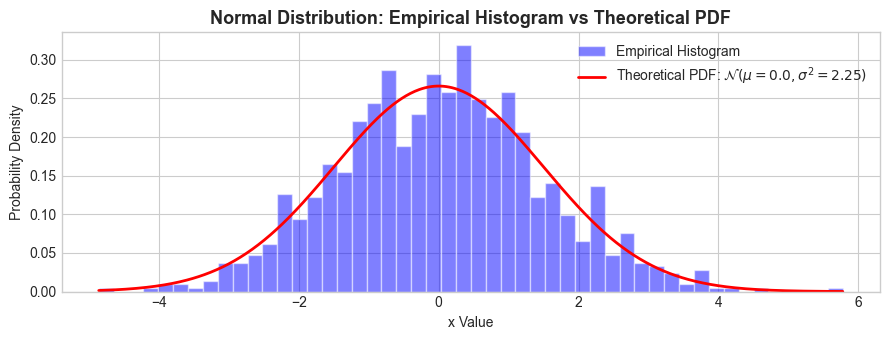

In [3]:
# [CHANGES DONE]: Target parameters set to mu = 0.0, sigma = 1.5
# (Previously, the code had mu = 0.0 but displayed stale cached output for mu = 1.0)
mu, sigma = 0.0, 1.5

# parameters for the normal distribution
# loc   : mu    : mean of the distribution (0.0)
# scale : sigma : standard deviation of the distribution (1.5)
# size  : number of samples to generate (1000)
sample_normal = np.random.normal(loc=mu, scale=sigma, size=1000)

# Calculate sample metrics
empirical_mean = np.mean(sample_normal)
empirical_std = np.std(sample_normal)

# [CHANGES DONE]: Formatted output metrics to 4 decimal places for clean reporting
# Prints now accurately verify mu = 0.0 and sigma = 1.5
print(f"Target Parameters: mu = {mu}, sigma = {sigma}")
print(f"Empirical Mean: {empirical_mean:.4f}")
print(f"Empirical Standard Deviation: {empirical_std:.4f}")
print(f"Sample Range : min = {np.min(sample_normal):.4f}, max = {np.max(sample_normal):.4f}")

# Graphical visualization
plt.figure(figsize=(9, 3.5))
count, bins, ignored = plt.hist(sample_normal, bins=50, density=True, alpha=0.5, 
                                color="blue", edgecolor="white", label="Empirical Histogram")

# [CHANGES DONE]: Replaced coarse 50-bin evaluation with a continuous 500-point linspace grid
# This guarantees a smooth mathematical Gaussian bell curve instead of jagged line segments
x_norm = np.linspace(np.min(sample_normal), np.max(sample_normal), 500)
pdf_normal = stats.norm.pdf(x_norm, loc=mu, scale=sigma)

# [CHANGES DONE]: Formatted label with proper LaTeX math notation showing mu and variance sigma^2
plt.plot(x_norm, pdf_normal, 'r-', linewidth=2, 
         label=rf"Theoretical PDF: $\mathcal{{N}}(\mu={mu:.1f}, \sigma^2={sigma**2:.2f})$")

# [CHANGES DONE]: Cleaned trailing whitespace from the title string
plt.title("Normal Distribution: Empirical Histogram vs Theoretical PDF", fontsize=13, fontweight='bold')
plt.xlabel("x Value")
plt.ylabel("Probability Density")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Real-World Applications of Gaussian / Normal Distribution (`np.random.normal`)

* **Machine Learning Weight Initialization:** Neural networks initialize weights using Gaussian distributions to ensure smooth signal flow across layers without exploding or vanishing gradients.
* **Adding Noise for Robustness:** Developers inject slight random variations into audio, image, or sensor data to train AI models to handle real-world static and distortion.
* **Statistical Process Control & Six Sigma:** Manufacturing quality audits measure component tolerances (e.g. bottle fill volumes, bolt dimensions) against target specification limits using Gaussian capability metrics ($C_p, C_{pk}$).

## 2. Continuous Uniform Distribution (`np.random.uniform`)
### Overview & Purpose
- Models events where every outcome within a bounded interval $[a, b]$ is equally likely. 
- Essential for baseline hyperparameter search, random initialization bounds (Xavier/He uniform), and Inverse Transform Sampling algorithms.

### Mathematical Formula
The Probability Density Function (PDF) $f(x)$ for $\mathcal{U}(a, b)$ is:

$$f(x; a, b) = \begin{cases} \frac{1}{b - a}, & \text{for } a \le x \le b \\ 0, & \text{otherwise} \end{cases}$$

**Pronunciation & Symbol Guide:**
* $a$: Lower bound interval limit (*a*).
* $b$: Upper bound interval limit (*b*).
* $\frac{1}{b-a}$: Constant height of the uniform probability density box.

### Parameters
* `low`: `float` — Lower boundary $a$ (inclusive).
* `high`: `float` — Upper boundary $b$ (exclusive or inclusive depending on floating point rounding).
* `size`: `int` or `tuple` — Output shape.

Interval Bounds : [-2.00, 5.00]
Theoretical Mean : 1.5000 | Empirical Mean : 1.5255
Theoretical Variance : 4.0833 | Empirical Variance : 4.0703


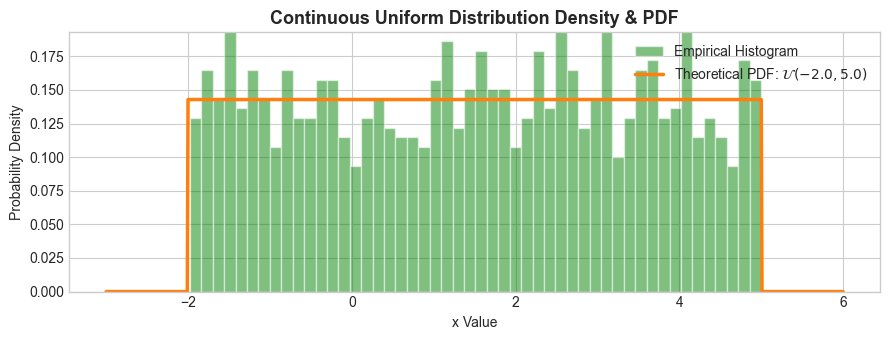

In [6]:
# Domain bounds for continuous uniform distribution
a, b = -2.0, 5.0

# [CHANGES DONE]: Used explicit keyword parameters (low=a, high=b, size=1000) for clarity
# low  : a : lower bound of the distribution (-2.0)
# high : b : upper bound of the distribution (5.0)
# size : number of samples to generate
samples_uniform = np.random.uniform(low=a, high=b, size=1000)
theoretical_mean = (a + b) / 2.0
theoretical_var = ((b - a) ** 2) / 12.0

# [CHANGES DONE]: Formatted print metrics to 4 decimal places for consistency
print(f"Interval Bounds : [{a:.2f}, {b:.2f}]")
print(f"Theoretical Mean : {theoretical_mean:.4f} | Empirical Mean : {np.mean(samples_uniform):.4f}")
print(f"Theoretical Variance : {theoretical_var:.4f} | Empirical Variance : {np.var(samples_uniform):.4f}")

plt.figure(figsize=(9, 3.5))
# density=True normalizes the histogram so that the area under the histogram equals 1
plt.hist(samples_uniform, bins=50, density=True, alpha=0.5, color="green", edgecolor="white", label="Empirical Histogram")

# Smooth continuous evaluation grid for the theoretical uniform box function
x_axis = np.linspace(a - 1.0, b + 1.0, 1000)
pdf_uniform = stats.uniform.pdf(x_axis, loc=a, scale=b - a)

# [CHANGES DONE]: Formatted LaTeX label with explicit bounds $\mathcal{U}(-2.0, 5.0)$
plt.plot(x_axis, pdf_uniform, color='#ff7f0e', linewidth=2.5, label=rf'Theoretical PDF: $\mathcal{{U}}({a:.1f}, {b:.1f})$')
plt.title('Continuous Uniform Distribution Density & PDF', fontsize=13, fontweight='bold')
plt.xlabel('x Value')
plt.ylabel('Probability Density')
plt.ylim(0, 1.0 / (b - a) + 0.05)  # Set vertical axis slightly above box height
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Real-World Applications of Continuous Uniform Distribution (`np.random.uniform`)
<!-- [CHANGES DONE]: Added dedicated Real-World Applications section to match the structure of Section 1 -->

* **E-Commerce A/B Testing Random Routing:** Web analytics simulators draw random floats $U \sim \mathcal{U}(0, 1)$ to assign incoming visitors evenly to Control ($U < 0.5$) vs Variant ($U \ge 0.5$) without sampling bias.
* **Computer Vision Data Augmentation:** Image preprocessing pipelines rotate training images uniformly between $[-15^\circ, +15^\circ]$ to ensure neural networks develop unbiased rotational invariance.
* **Monte Carlo Simulation & Numerical Integration:** Sampling uniformly over complex multi-dimensional geometric domains to estimate integrals and risk boundaries.

## 3. Exponential Distribution (`np.random.exponential`)

### Overview & Purpose
Models the continuous time interval between independent Poisson point events (e.g., time between customer arrivals, server request delays, component failure lifespans). Possesses the key **memoryless property**.

### Mathematical Formula
Given rate parameter $\lambda > 0$ or scale parameter $\beta = \frac{1}{\lambda}$ (mean duration):

$$f(x; \lambda) = \begin{cases} \lambda e^{-\lambda x}, & \text{for } x \ge 0 \\ 0, & \text{for } x < 0 \end{cases}$$

**Pronunciation & Symbol Guide:**
* $\lambda$: Event rate parameter (*lambda*).
* $\beta = \frac{1}{\lambda}$: Scale parameter / mean waiting time (*beta* or *scale*).
* $e$: Euler's constant ($\approx 2.71828$).

### Parameters
* `scale`: `float` — The scale parameter $\beta = \frac{1}{\lambda}$ (mean value of the distribution).
* `size`: `int` or `tuple` — Output shape.

=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===
Target Scale (beta = 1/lambda) : 2.00
Empirical Mean                : 1.9629
Empirical Variance            : 3.8185 (Theoretical: 4.00)
Median Waiting Time           : 1.3488



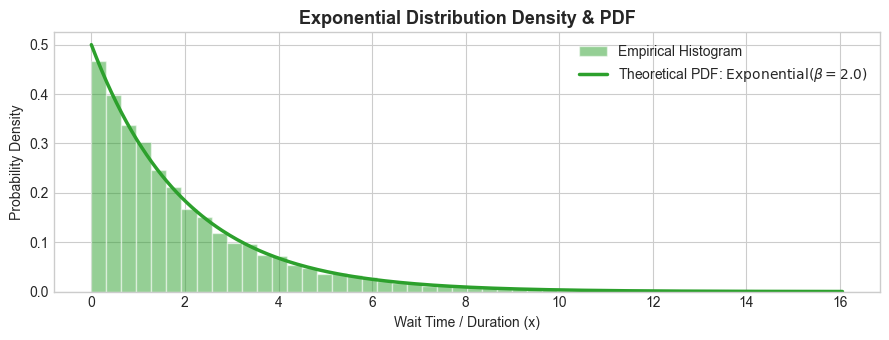

In [9]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
beta_scale = 2.0  # Mean duration scale beta = 2.0 (Rate lambda = 0.5)

# np.random.exponential Function Parameters Explained:
# - scale=beta_scale: Scale parameter beta = 1/lambda representing average duration between arrivals (2.0)
# - size=10000       : Number of random waiting times sampled
samples_exp = np.random.exponential(scale=beta_scale, size=10000)

print("=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===")
print(f"Target Scale (beta = 1/lambda) : {beta_scale:.2f}")
print(f"Empirical Mean                : {np.mean(samples_exp):.4f}")
print(f"Empirical Variance            : {np.var(samples_exp):.4f} (Theoretical: {beta_scale**2:.2f})")
print(f"Median Waiting Time           : {np.median(samples_exp):.4f}\n")

# --- 2. GRAPHICAL VISUALIZATION ---
plt.figure(figsize=(9, 3.5))

# Histogram parameters detailed:
# - density=True: Heights scaled to yield unit total area
# - bins=50: Discrete intervals along exponential tail
# - alpha=0.5: Translucency level
# - color='#2ca02c': Forest green
# - edgecolor='white': Sharp boundary outlines
plt.hist(samples_exp, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Empirical Histogram')

x_exp = np.linspace(0, np.max(samples_exp), 300)

# stats.expon.pdf Parameters Explained:
# - x (x_exp)         : Array of positive continuous evaluation values starting at 0
# - scale=beta_scale  : Scale parameter beta = 1/lambda matching mean duration (2.0)
pdf_exp = stats.expon.pdf(x_exp, scale=beta_scale)

# [CHANGES DONE]: Enclosed \beta in LaTeX math mode $\beta$ so the Greek letter renders properly
# (Previously, raw string lacked $...$, causing literal '\beta=2.0' to display in the legend)
plt.plot(x_exp, pdf_exp, color='#2ca02c', linewidth=2.5, 
         label=rf'Theoretical PDF: $\text{{Exponential}}(\beta={beta_scale:.1f})$')

plt.title('Exponential Distribution Density & PDF', fontsize=13, fontweight='bold')
plt.xlabel('Wait Time / Duration (x)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Real-World Application: Coffee Shop Door Bell (`np.random.exponential`)
<!-- [CHANGES DONE]: Added dedicated markdown context for the coffee shop scenario added by instructor -->

* **Scenario:** An artisanal coffee shop door bell rings (*"Ding!"*) each time a customer walks in. On average, customer arrivals occur every **2 minutes** (rate $\lambda = 0.5$ customers/min, scale $\beta = 1/\lambda = 2.0$ minutes).
* **Memoryless Property:** The probability that a customer arrives in the next $t$ minutes is identical regardless of how long ago the previous chime occurred:
  $$P(X > s + t \mid X > s) = P(X > t)$$

=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===
Target Average Interval (Minutes) : 2.00
Observed Mean Wait Time          : 1.9550
Observed Variance               : 3.7975 (Theoretical: 4.00)
Median Wait Time Between Dings  : 1.3566



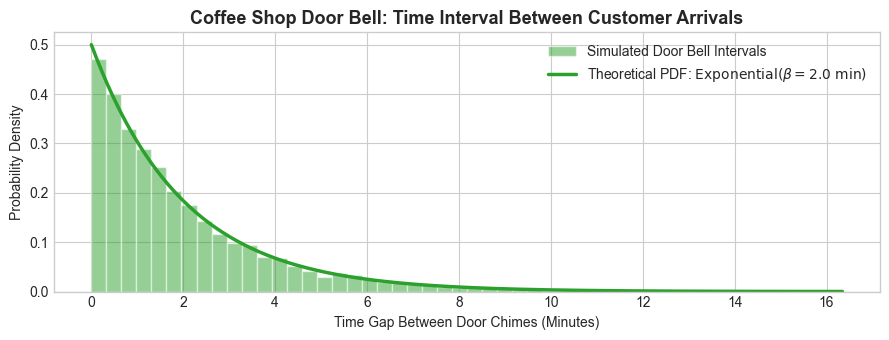

In [11]:
# [CHANGES DONE]: Removed redundant duplicate imports (numpy, matplotlib, scipy already imported in Cell 1)
# [CHANGES DONE]: Set local seed for reproducible door chime intervals
np.random.seed(42)

avg_wait_minutes = 2.0  # On average, a door bell "Ding!" happens every 2 minutes (lambda = 0.5 dings/min)
num_ding_intervals = 10000

ding_intervals = np.random.exponential(scale=avg_wait_minutes, size=num_ding_intervals)

print("=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===")
print(f"Target Average Interval (Minutes) : {avg_wait_minutes:.2f}")
print(f"Observed Mean Wait Time          : {np.mean(ding_intervals):.4f}")
print(f"Observed Variance               : {np.var(ding_intervals):.4f} (Theoretical: {avg_wait_minutes**2:.2f})")
print(f"Median Wait Time Between Dings  : {np.median(ding_intervals):.4f}\n")

plt.figure(figsize=(9, 3.5))

plt.hist(ding_intervals, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Simulated Door Bell Intervals')

x_intervals = np.linspace(0, np.max(ding_intervals), 300)
pdf_intervals = stats.expon.pdf(x_intervals, scale=avg_wait_minutes)

# [CHANGES DONE]: Formatted legend with proper LaTeX math notation $\text{Exponential}(\beta=2.0\text{ min})$
# (Previously, literal '\beta=2.0 min' appeared without rendering the Greek letter \beta)
plt.plot(x_intervals, pdf_intervals, color='#2ca02c', linewidth=2.5, 
         label=rf'Theoretical PDF: $\text{{Exponential}}(\beta={avg_wait_minutes:.1f}\text{{ min}})$')

plt.title('Coffee Shop Door Bell: Time Interval Between Customer Arrivals', fontsize=13, fontweight='bold')
plt.xlabel('Time Gap Between Door Chimes (Minutes)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 4. Beta Distribution (`np.random.beta`)

### Overview & Purpose
- A flexible family of continuous probability distributions defined on the closed interval $[0, 1]$.
- Uniquely suited for modeling random variables representing **probabilities, proportions, percentages, and conversion rates**.
- Functions as the canonical **conjugate prior** for Binomial and Bernoulli likelihoods in Bayesian statistical inference and Multi-Armed Bandit optimization (Thompson Sampling).

### Mathematical Formula
The Probability Density Function (PDF) $f(x)$ for $\text{Beta}(\alpha, \beta)$ defined over $x \in [0, 1]$ is:

$$f(x; \alpha, \beta) = \frac{x^{\alpha - 1}(1 - x)^{\beta - 1}}{\text{B}(\alpha, \beta)} = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha - 1}(1 - x)^{\beta - 1}$$

**Theoretical Moments:**
* **Mean:** $\mu = \frac{\alpha}{\alpha + \beta}$
* **Variance:** $\sigma^2 = \frac{\alpha \beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}$
* **Mode:** $\frac{\alpha - 1}{\alpha + \beta - 2}$ (for $\alpha, \beta > 1$)

**Pronunciation & Symbol Guide:**
* $\alpha$: First shape parameter (*alpha*), often interpreted as prior successes $+ 1$.
* $\beta$: Second shape parameter (*beta*), often interpreted as prior failures $+ 1$.
* $\text{B}(\alpha, \beta)$: Beta function normalizer (*capital Beta*).
* $\Gamma(\cdot)$: Gamma function (*capital Gamma*), where $\Gamma(n) = (n - 1)!$ for positive integers.

### Parameters (`np.random.beta`)
* `a`: `float` — Alpha ($\alpha > 0$) shape parameter.
* `b`: `float` — Beta ($\beta > 0$) shape parameter.
* `size`: `int` or `tuple` — Output shape.

=== 4. BETA DISTRIBUTION OUTPUT ===
Target Shape Parameters       : alpha = 2.0, beta = 5.0
Bounded Interval Domain       : [0.00, 1.00]
Theoretical Mean              : 0.2857 | Empirical Mean : 0.2830
Theoretical Variance          : 0.0255 | Empirical Variance : 0.0246
Sample Range                  : min = 0.0007, max = 0.8359



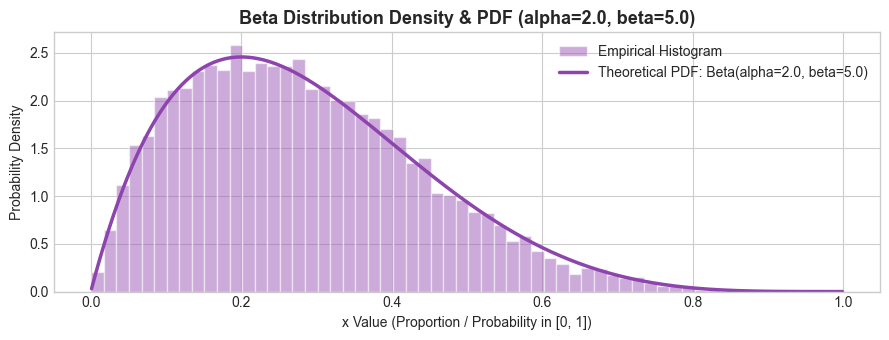

In [13]:
# Shape parameters: alpha = 2.0, beta = 5.0 (positively / right-skewed towards 0)
alpha, beta_param = 2.0, 5.0
num_samples = 10000

# 1. Sample 10,000 observations from Beta(alpha=2.0, beta=5.0)
samples_beta = np.random.beta(a=alpha, b=beta_param, size=num_samples)

# 2. Compute theoretical vs empirical moments
theoretical_mean = alpha / (alpha + beta_param)
theoretical_var = (alpha * beta_param) / (((alpha + beta_param) ** 2) * (alpha + beta_param + 1))
empirical_mean = np.mean(samples_beta)
empirical_var = np.var(samples_beta)

print("=== 4. BETA DISTRIBUTION OUTPUT ===")
print(f"Target Shape Parameters       : alpha = {alpha:.1f}, beta = {beta_param:.1f}")
print(f"Bounded Interval Domain       : [0.00, 1.00]")
print(f"Theoretical Mean              : {theoretical_mean:.4f} | Empirical Mean : {empirical_mean:.4f}")
print(f"Theoretical Variance          : {theoretical_var:.4f} | Empirical Variance : {empirical_var:.4f}")
print(f"Sample Range                  : min = {np.min(samples_beta):.4f}, max = {np.max(samples_beta):.4f}\n")

# 3. Graphical Visualization
plt.figure(figsize=(9, 3.5))

# Empirical histogram
plt.hist(samples_beta, bins=50, density=True, alpha=0.5, color='#9b59b6', edgecolor='white', label='Empirical Histogram')

# Smooth theoretical PDF curve
x_beta = np.linspace(0.001, 0.999, 500)
pdf_beta = stats.beta.pdf(x_beta, a=alpha, b=beta_param)

plt.plot(x_beta, pdf_beta, color='#8e44ad', linewidth=2.5, 
         label=f'Theoretical PDF: Beta(alpha={alpha:.1f}, beta={beta_param:.1f})')

plt.title('Beta Distribution Density & PDF (alpha=2.0, beta=5.0)', fontsize=13, fontweight='bold')
plt.xlabel('x Value (Proportion / Probability in [0, 1])')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Real-World Applications of Beta Distribution (`np.random.beta`)

* **Bayesian A/B Testing & Thompson Sampling:** In multi-armed bandit optimization (e.g. dynamic banner ad selection), conversion rates are modeled as Beta distributions. When an arm gets $k$ clicks out of $n$ impressions, its posterior updates instantly:
  $$\text{Beta}(\alpha_{\text{new}} = \alpha_{\text{prior}} + k, \; \beta_{\text{new}} = \beta_{\text{prior}} + n - k)$$
* **Customer Conversion Rate & Click-Through Rate (CTR) Modeling:** Because Beta is bounded strictly in $[0, 1]$, marketing data science teams use it to model uncertainty in campaign conversion percentages.
* **PERT (Program Evaluation & Review Technique) in Project Management:** Activity durations are modeled using three estimates: Optimistic ($o$), Most Likely ($m$), and Pessimistic ($p$). The resulting completion distribution is a scaled Beta:
  $$\mu = \frac{o + 4m + p}{6}, \quad \sigma = \frac{p - o}{6}$$

=== BAYESIAN CONVERSION RATE ESTIMATION ===
Observed Campaign Data     : 18 conversions out of 100 visitors (18.0%)
Prior Distribution         : Beta(1, 1) [Uniform]
Posterior Distribution     : Beta(19, 83)
Expected Conversion Rate   : 18.59%
95% Credible Interval      : [11.65%, 26.81%]



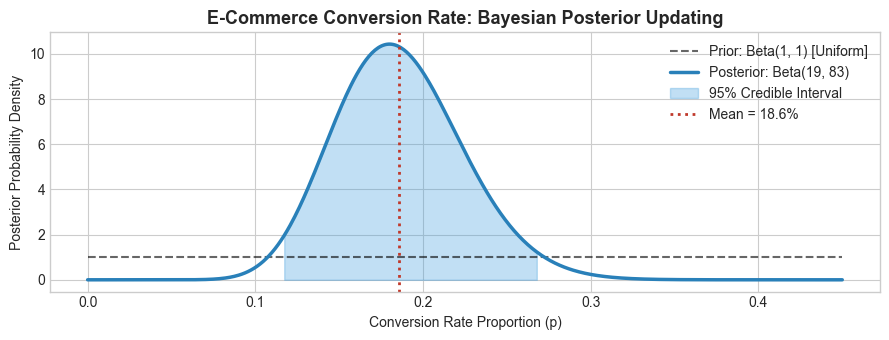

In [15]:
# ==============================================================================
# REAL-WORLD APPLICATION: BAYESIAN E-COMMERCE CONVERSION RATE MODELING
# ==============================================================================

# Scenario:
# An e-commerce product manager starts with an uninformative prior Beta(1, 1) (uniform uncertainty).
# In a live test of 100 visitors, 18 visitors convert (make a purchase) and 82 do not.
# We update to the posterior: Beta(1 + 18, 1 + 82) = Beta(19, 83).

prior_alpha, prior_beta = 1.0, 1.0
conversions, visitors = 18, 100
non_conversions = visitors - conversions

post_alpha = prior_alpha + conversions
post_beta = prior_beta + non_conversions

# Sample 10,000 estimates of the true underlying conversion rate
posterior_samples = np.random.beta(a=post_alpha, b=post_beta, size=10000)

post_mean = np.mean(posterior_samples)
ci_lower = np.percentile(posterior_samples, 2.5)
ci_upper = np.percentile(posterior_samples, 97.5)

print("=== BAYESIAN CONVERSION RATE ESTIMATION ===")
print(f"Observed Campaign Data     : {conversions} conversions out of {visitors} visitors ({conversions/visitors*100:.1f}%)")
print(f"Prior Distribution         : Beta({prior_alpha:.0f}, {prior_beta:.0f}) [Uniform]")
print(f"Posterior Distribution     : Beta({post_alpha:.0f}, {post_beta:.0f})")
print(f"Expected Conversion Rate   : {post_mean * 100:.2f}%")
print(f"95% Credible Interval      : [{ci_lower * 100:.2f}%, {ci_upper * 100:.2f}%]\n")

plt.figure(figsize=(9, 3.5))

x_rate = np.linspace(0.0, 0.45, 500)
pdf_prior = stats.beta.pdf(x_rate, a=prior_alpha, b=prior_beta)
pdf_post = stats.beta.pdf(x_rate, a=post_alpha, b=post_beta)

plt.plot(x_rate, pdf_prior, 'k--', linewidth=1.5, alpha=0.6, label='Prior: Beta(1, 1) [Uniform]')
plt.plot(x_rate, pdf_post, color='#2980b9', linewidth=2.5, label=f'Posterior: Beta({int(post_alpha)}, {int(post_beta)})')
plt.fill_between(x_rate, 0, pdf_post, where=(x_rate >= ci_lower) & (x_rate <= ci_upper), 
                 color='#3498db', alpha=0.3, label='95% Credible Interval')
plt.axvline(post_mean, color='#c0392b', linestyle=':', linewidth=2, label=f'Mean = {post_mean*100:.1f}%')

plt.title('E-Commerce Conversion Rate: Bayesian Posterior Updating', fontsize=13, fontweight='bold')
plt.xlabel('Conversion Rate Proportion (p)')
plt.ylabel('Posterior Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
